# NYC MTA Ridership Analysis (2020–2025)

**Goal:** From the perspective of a commuter who lives in New Jersey, which NYC transit mode is the least crowded and can we predict it using calendar-based features?

This notebook covers:
1. Data loading & cleaning
2. Long-term trend analysis (30-day rolling averages)
3. Crowdedness by day of week and holiday status
4. Seasonal effects via linear regression
5. Random Forest classification: predicting the least-crowded mode


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holidays
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42


## 2. Load Data

In [2]:
# Load Data:
#parsing dates allows it to be read in as Monday, Tuesday, etc.
mta_data = pd.read_csv("MTA_Daily_Ridership_Data__2020_-_2025.csv", parse_dates=['Date'])
mta_data.head()

,Date,Subways: Total Estimated Ridership,Subways: % of Comparable Pre-Pandemic Day,Buses: Total Estimated Ridership,Buses: % of Comparable Pre-Pandemic Day,LIRR: Total Estimated Ridership,LIRR: % of Comparable Pre-Pandemic Day,Metro-North: Total Estimated Ridership,Metro-North: % of Comparable Pre-Pandemic Day,Access-A-Ride: Total Scheduled Trips,Access-A-Ride: % of Comparable Pre-Pandemic Day,Bridges and Tunnels: Total Traffic,Bridges and Tunnels: % of Comparable Pre-Pandemic Day,Staten Island Railway: Total Estimated Ridership,Staten Island Railway: % of Comparable Pre-Pandemic Day
0,2021-01-01,613692,0.29,378288,0.41,28977,0.35,14988,0.17,5960,0.44,445950,0.65,805,0.29
1,2022-01-01,1027918,0.38,350845,0.29,33980,0.35,30341,0.23,4904,0.34,498515,0.65,1262,0.31
2,2023-01-01,1675507,0.80,475226,0.52,67722,0.82,66309,0.73,11476,0.85,737533,1.08,1771,0.65
3,2024-01-01,1648734,0.79,455965,0.50,82811,1.00,73957,0.82,9165,0.68,730489,1.07,2018,0.74
4,2025-01-01,1779352,0.85,495795,0.54,90318,1.09,74690,0.83,12417,0.92,678296,0.99,2040,0.75


## 3. Data Cleaning & Feature Engineering

In [3]:
df = mta_data.copy()
df = df.dropna().sort_values('Date').reset_index(drop=True)

# Parse dates and extract calendar features
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.day_name()
df['is_weekend'] = df['Date'].dt.dayofweek >= 5

# Season
def get_season(date):
    m = date.month
    if m in [12, 1, 2]: return 'Winter'
    if m in [3, 4, 5]: return 'Spring'
    if m in [6, 7, 8]: return 'Summer'
    return 'Fall'
df['season'] = df['Date'].apply(get_season)

# US federal holidays
YEARS = list(range(2020, 2026))
HOLIDAY_NAMES = {
    "New Year's Day", 
    "Martin Luther King Jr. Day", 
    "Memorial Day",
    "Independence Day", 
    "Labor Day", "Thanksgiving", 
    "Christmas Day",
    "New Year's Day (Observed)", 
    "Martin Luther King Jr. Day (Observed)",
    "Memorial Day (Observed)", 
    "Independence Day (Observed)",
    "Labor Day (Observed)", 
    "Thanksgiving (Observed)", 
    "Christmas Day (Observed)"
}
filtered_holidays = {k: v for k, v in holidays.US(years=YEARS).items() if v in HOLIDAY_NAMES}
df['is_holiday'] = df['Date'].dt.date.isin(filtered_holidays.keys()).astype(int)

print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Holidays flagged: {df["is_holiday"].sum()}')
df.dtypes


Shape: (1776, 22)
Date range: 2020-03-01 to 2025-01-09
Holidays flagged: 29


Date                                                       datetime64[ns]
Subways: Total Estimated Ridership                                  int64
Subways: % of Comparable Pre-Pandemic Day                         float64
Buses: Total Estimated Ridership                                    int64
Buses: % of Comparable Pre-Pandemic Day                           float64
LIRR: Total Estimated Ridership                                     int64
LIRR: % of Comparable Pre-Pandemic Day                            float64
Metro-North: Total Estimated Ridership                              int64
Metro-North: % of Comparable Pre-Pandemic Day                     float64
Access-A-Ride: Total Scheduled Trips                                int64
Access-A-Ride: % of Comparable Pre-Pandemic Day                   float64
Bridges and Tunnels: Total Traffic                                  int64
Bridges and Tunnels: % of Comparable Pre-Pandemic Day             float64
Staten Island Railway: Total Estimated

## 4. Long-Term Ridership Trends

30-day rolling averages smooth out day-to-day noise and reveal the pandemic recovery trajectory for each mode.

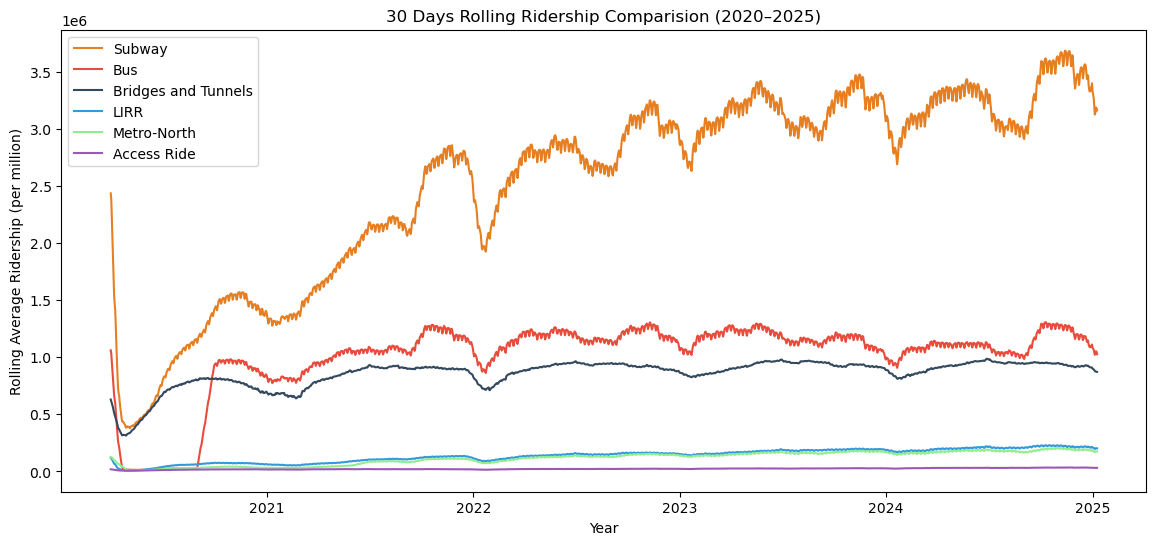

In [4]:
subway_daily = (df.set_index("Date")["Subways: Total Estimated Ridership"].sort_index())
tunnels_bridges_daily = (df.set_index("Date")["Bridges and Tunnels: Total Traffic"].sort_index())
bus_daily = (df.set_index("Date")["Buses: Total Estimated Ridership"].sort_index())
LIRR_daily = (df.set_index("Date")["LIRR: Total Estimated Ridership"].sort_index())
Metro_daily = (df.set_index("Date")["Metro-North: Total Estimated Ridership"].sort_index())
A_Ride_daily = (df.set_index("Date")["Access-A-Ride: Total Scheduled Trips"].sort_index())


rolling_30_days_subway = subway_daily.rolling(window=30).mean() #avg ridership for subway every 30 days
rolling_30_days_tunnels_bridges = tunnels_bridges_daily.rolling(window=30).mean() #avg ridership for tunnels and bridges every 30 days
rolling_30_days_bus = bus_daily.rolling(window=30).mean() #avg ridership for buses every 30 days
rolling_30_days_LIRR = LIRR_daily.rolling(window=30).mean() #avg ridership for LIRR every 30 days
rolling_30_days_Metro = Metro_daily.rolling(window=30).mean() #avg ridership for Metro-North every 30 days
rolling_30_days_A_Ride = A_Ride_daily.rolling(window=30).mean() #avg ridership for Access Ride every 30 days

plt.figure(figsize=(14,6))
plt.plot(rolling_30_days_subway.index,rolling_30_days_subway.values,color="#e67e22",label="Subway")
plt.plot(rolling_30_days_bus.index,rolling_30_days_bus.values,color="#e74c3c",label="Bus")
plt.plot(rolling_30_days_tunnels_bridges.index,rolling_30_days_tunnels_bridges.values,color="#34495e",label="Bridges and Tunnels")
plt.plot(rolling_30_days_LIRR.index,rolling_30_days_LIRR.values,color="#3498db",label="LIRR")
plt.plot(rolling_30_days_Metro.index,rolling_30_days_Metro.values,color="#90ee90",label="Metro-North")
plt.plot(rolling_30_days_A_Ride.index,rolling_30_days_A_Ride.values,color="#9b59b6",label="Access Ride")


plt.title("30 Days Rolling Ridership Comparision (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Rolling Average Ridership (per million)")
plt.legend()
plt.show()

## 5. Crowdedness by Day of Week

Average ridership per mode, grouped by day of week. Weekdays dominate commuter rail (LIRR, Metro-North), while buses and subways are more consistent.

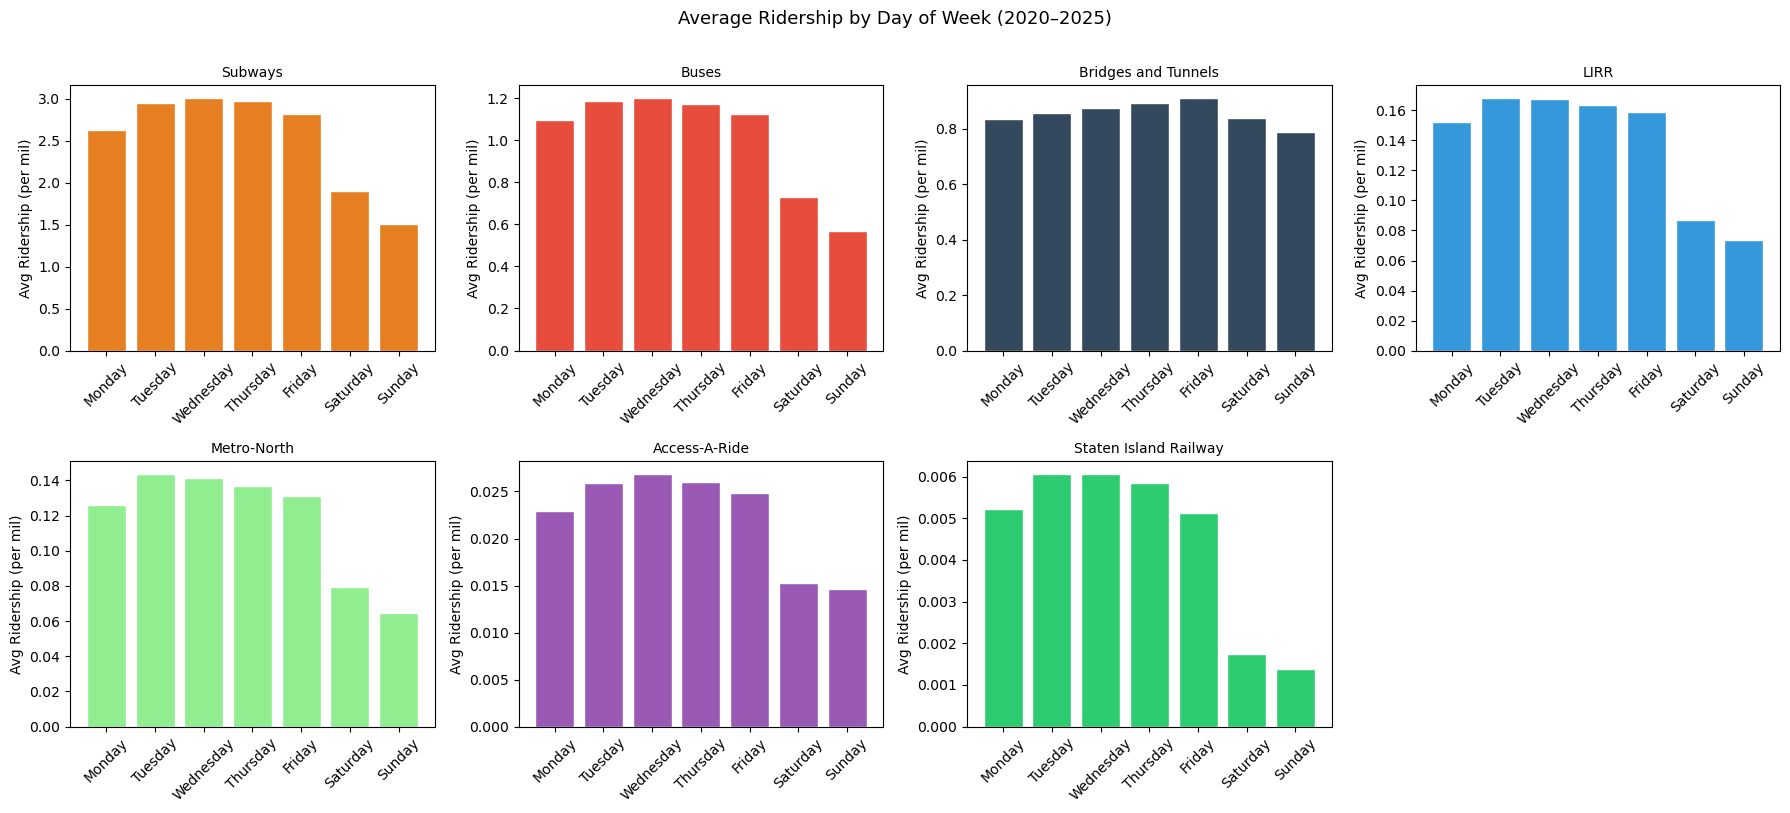

In [5]:
TRANSPORT_COLS = [
    'Subways: Total Estimated Ridership',
    'Buses: Total Estimated Ridership',
    'Bridges and Tunnels: Total Traffic',
    'LIRR: Total Estimated Ridership',
    'Metro-North: Total Estimated Ridership',
    'Access-A-Ride: Total Scheduled Trips',
    'Staten Island Railway: Total Estimated Ridership',
]

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_day = df.groupby('dayofweek')[TRANSPORT_COLS].mean().reindex(DAY_ORDER)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = ['#e67e22', '#e74c3c', '#34495e', '#3498db', '#90ee90', '#9b59b6', '#2ecc71']

for i, (col, color) in enumerate(zip(TRANSPORT_COLS, colors)):
    axes[i].bar(DAY_ORDER, avg_by_day[col] / 1e6, color=color, edgecolor='white')
    axes[i].set_title(col.split(':')[0], fontsize=10)
    axes[i].set_ylabel('Avg Ridership (per mil)')
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)  # hide unused subplot
plt.suptitle('Average Ridership by Day of Week (2020–2025)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 6. Holiday vs. Non-Holiday Ridership

How much does a federal holiday suppress ridership across each mode?

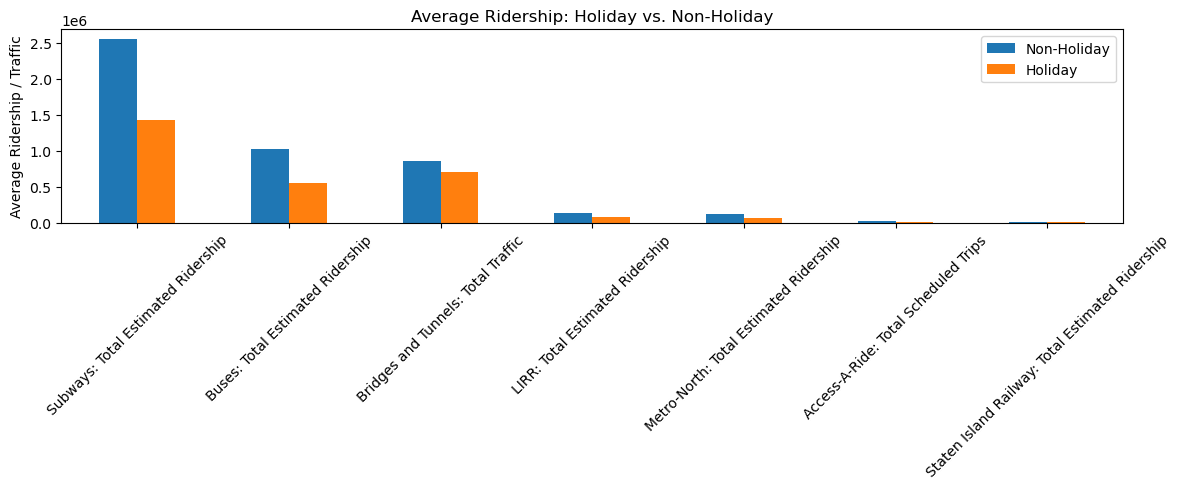

% drop on holidays:
Subways: Total Estimated Ridership                  44.2
Buses: Total Estimated Ridership                    46.5
Bridges and Tunnels: Total Traffic                  17.5
LIRR: Total Estimated Ridership                     44.1
Metro-North: Total Estimated Ridership              51.1
Access-A-Ride: Total Scheduled Trips                48.9
Staten Island Railway: Total Estimated Ridership    59.5


In [6]:
holiday_means = df.groupby('is_holiday')[TRANSPORT_COLS].mean()
holiday_means.index = ['Non-Holiday', 'Holiday']

ax = holiday_means.T.plot(kind='bar', figsize=(12, 5), rot=45)
ax.set_title('Average Ridership: Holiday vs. Non-Holiday')
ax.set_ylabel('Average Ridership / Traffic')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

pct_drop = ((holiday_means.loc['Non-Holiday'] - holiday_means.loc['Holiday'])
            / holiday_means.loc['Non-Holiday'] * 100).round(1)
print('% drop on holidays:')
print(pct_drop.to_string())


## 7. Predicting Subway Ridership from Day & Holiday

Visualize Actual vs. Predicted Values using a scatter plot comparing the actual test set values (y_test) with the model's predicted values (y_test_pred). The diagonal line represents perfect predictions for reference.

RMSE: 934,358
R²:   0.230


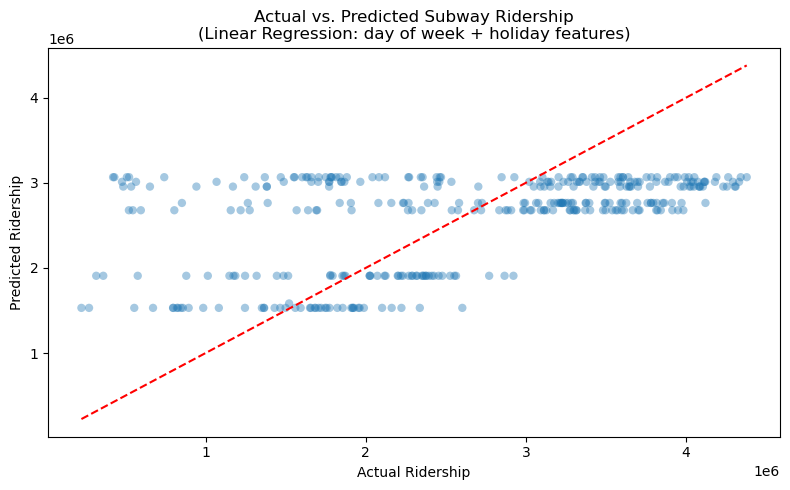

In [7]:
X = df[['dayofweek', 'is_holiday']].copy()
X = pd.get_dummies(X, columns=['dayofweek'], drop_first=True)
y = df['Subways: Total Estimated Ridership']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"RMSE: {mean_squared_error(y_test, y_pred)**0.5:,.0f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual Ridership')
plt.ylabel('Predicted Ridership')
plt.title('Actual vs. Predicted Subway Ridership\n(Linear Regression: day of week + holiday features)')
plt.tight_layout()
plt.show()

## 8. Can We Predict Bridge & Tunnel Traffic from Transit Ridership?
Car traffic (Bridges & Tunnels) is the main alternative for an NJ commuter. 
Here we test whether other transit modes can predict it. If subway and bus riderships are high, do fewer people drive? Five models are compared and the best performer is used for the actual vs. predicted plot.

Linear Regression     RMSE:     72,096  R²: 0.724
Ridge                 RMSE:     72,096  R²: 0.724
Lasso                 RMSE:     72,096  R²: 0.724
Decision Tree         RMSE:     57,324  R²: 0.825
Random Forest         RMSE:     44,832  R²: 0.893

Best model: Random Forest


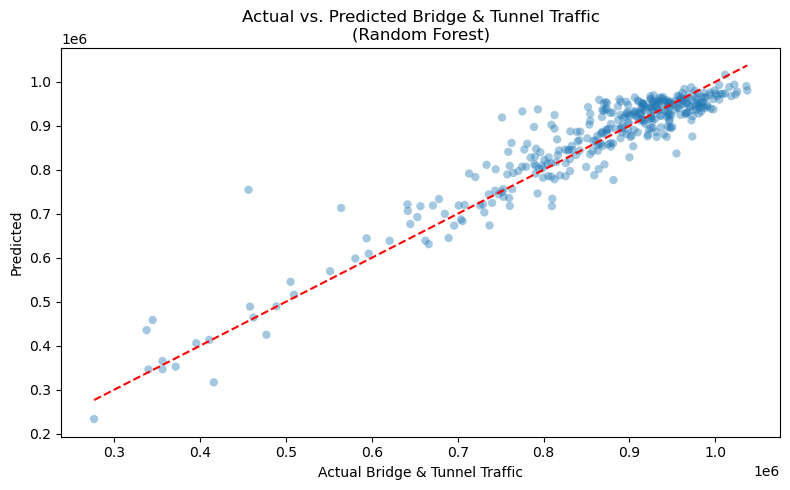

In [8]:
X = df[[
    'Subways: Total Estimated Ridership',
    'Buses: Total Estimated Ridership',
    'LIRR: Total Estimated Ridership',
    'Metro-North: Total Estimated Ridership',
    'Access-A-Ride: Total Scheduled Trips',
    'Staten Island Railway: Total Estimated Ridership',
]].copy()
y = df['Bridges and Tunnels: Total Traffic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressors = [
    ('Linear Regression', LinearRegression()),
    ('Ridge',             Ridge()),
    ('Lasso',             Lasso()),
    ('Decision Tree',     DecisionTreeRegressor(random_state=42)),
    ('Random Forest',     RandomForestRegressor(n_estimators=100, random_state=42)),
]

results = {}
for name, reg in regressors:
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    results[name] = {
        'model': reg,
        'rmse':  mean_squared_error(y_test, y_pred) ** 0.5,
        'r2':    r2_score(y_test, y_pred),
    }
    print(f"{name:20s}  RMSE: {results[name]['rmse']:>10,.0f}  R²: {results[name]['r2']:.3f}")

best_name = min(results, key=lambda k: results[k]['rmse'])
best_model = results[best_name]['model']
print(f"\nBest model: {best_name}")

# Plot actual vs predicted for best model
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_best, alpha=0.4, edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual Bridge & Tunnel Traffic')
plt.ylabel('Predicted')
plt.title(f'Actual vs. Predicted Bridge & Tunnel Traffic\n({best_name})')
plt.tight_layout()
plt.show()

## 9. Seasonal Effects (Linear Regression)

Fit a linear regression per transit mode with season dummies to quantify how much each season shifts ridership relative to Winter (baseline).

In [9]:
def get_season(date):
    month = date.month
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

df['season']=df['Date'].dt.date.apply(get_season)


In [10]:
df_dummy = df.copy()
df_dummy = pd.get_dummies(df_dummy,columns=['season'])
df_dummy = df_dummy.drop(columns=['season_Winter'])


In [11]:
modes = [
    'Subways: Total Estimated Ridership',
    'Buses: Total Estimated Ridership',
    'LIRR: Total Estimated Ridership',
    'Metro-North: Total Estimated Ridership',
    'Access-A-Ride: Total Scheduled Trips',
    'Bridges and Tunnels: Total Traffic'
]

result={}
feature_col=['season_Spring','season_Summer','season_Fall']

for mode in modes:
    x = df_dummy[feature_col]
    y = df_dummy[mode]

    split_idx = int(0.8 * len(df_dummy))
    x_train, x_test = x.iloc[:split_idx],x.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx],y.iloc[split_idx:]

    model = LinearRegression()
    model.fit(x_train,y_train)

    y_predict_train = model.predict(x_train)
    y_predict_test = model.predict(x_test)

    train_rmse = root_mean_squared_error(y_train,y_predict_train)
    test_rmse = root_mean_squared_error(y_test,y_predict_test)
    train_r2 = r2_score(y_train,y_predict_train)
    test_r2 = r2_score(y_test,y_predict_test)

    result[mode] = {
        'coefficients': model.coef_,
        'train_rmse':train_rmse,
        'test_rmse':test_rmse,
        'train_r2':train_r2,
        'test_r2':test_r2
    }

for mode, info in result.items():
    print("\nMode:", mode)
    print("Coefficients (Spring, Summer, Fall):", np.round(info['coefficients'], 3))
    print("Train RMSE:", round(info['train_rmse'], 3))
    print("Test RMSE:", round(info['test_rmse'], 3))
    print("Train R^2:", round(info['train_r2'], 3))
    print("Test R^2:", round(info['test_r2'], 3))



Mode: Subways: Total Estimated Ridership
Coefficients (Spring, Summer, Fall): [-125791.985 -117333.493  250628.956]
Train RMSE: 1033875.289
Test RMSE: 1215760.795
Train R^2: 0.022
Test R^2: -1.265

Mode: Buses: Total Estimated Ridership
Coefficients (Spring, Summer, Fall): [ -46092.232 -146495.412  129167.349]
Train RMSE: 450926.397
Test RMSE: 317646.132
Train R^2: 0.047
Test R^2: -0.171

Mode: LIRR: Total Estimated Ridership
Coefficients (Spring, Summer, Fall): [-8492.842  6957.748 21272.457]
Train RMSE: 64223.572
Test RMSE: 102093.573
Train R^2: 0.029
Test R^2: -1.994

Mode: Metro-North: Total Estimated Ridership
Coefficients (Spring, Summer, Fall): [-4762.321  4035.779 18430.953]
Train RMSE: 61100.17
Test RMSE: 92064.806
Train R^2: 0.02
Test R^2: -2.273

Mode: Access-A-Ride: Total Scheduled Trips
Coefficients (Spring, Summer, Fall): [-1142.512    75.721  1760.278]
Train RMSE: 6938.619
Test RMSE: 12811.91
Train R^2: 0.022
Test R^2: -2.477

Mode: Bridges and Tunnels: Total Traffic
Co

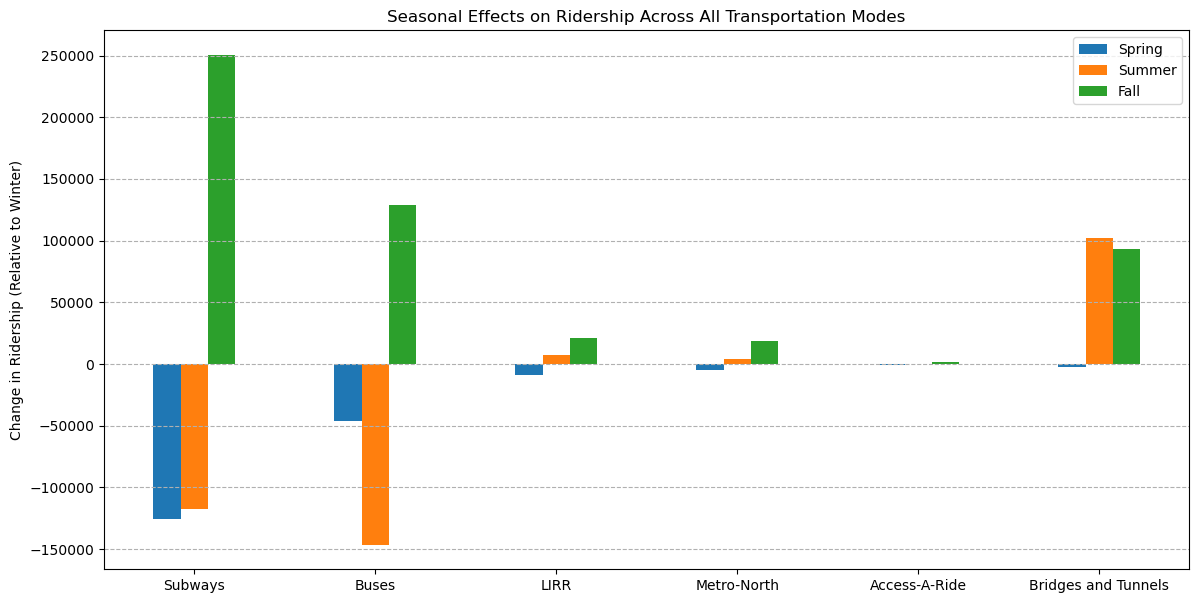

In [12]:
coef_matrix = np.array([result[mode]['coefficients'] for mode in modes])

plt.figure(figsize=(14, 7))
x = np.arange(len(modes))

for i, season in enumerate(['Spring', 'Summer', 'Fall']):
    plt.bar(x + i*0.15, coef_matrix[:, i], width=0.15, label=season)

plt.xticks(x + 0.15, [m.split(":")[0] for m in modes])
plt.ylabel("Change in Ridership (Relative to Winter)")
plt.title("Seasonal Effects on Ridership Across All Transportation Modes")
plt.grid(axis='y', linestyle='--')
plt.legend()
plt.show()


## 10. Predicting the Least-Crowded Mode

We frame this as a classification task: given the date's calendar features, predict which transit mode will have the **lowest normalized crowdedness** that day.

Modes are split into:
- **Inner-city:** Subway, Bus, Access-A-Ride, Staten Island Railway
- **Outer-city:** Metro-North, LIRR, Bridges & Tunnels

In [13]:
# base features
X = df[['dayofweek', 'month', 'is_holiday']].copy()

# add is_weekend flag
weekend_days = ['Saturday', 'Sunday']
df['is_weekend'] = df['dayofweek'].isin(weekend_days).astype(int)

# add season based on month
season_map = {
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'fall', 10: 'fall', 11: 'fall'
}
df['season'] = df['month'].map(season_map)

# add week_of_year
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)

# append engineered features to X
X['is_weekend'] = df['is_weekend']
X['season'] = df['season']
X['week_of_year'] = df['week_of_year']

#capacity helper function
def estimate_capacity(df, total_col, total_type):
    """
    Estimate capacity as: capacity = mean(ridership / percent_of_pre_pandemic)
    total_type is one of:
        - "Total Estimated Ridership"
        - "Total Scheduled Trips"
        - "Total Traffic"
    """
    if total_type == "Total Estimated Ridership":
        percent_col = total_col.replace("Total Estimated Ridership",
                                        "% of Comparable Pre-Pandemic Day")
    elif total_type == "Total Scheduled Trips":
        percent_col = total_col.replace("Total Scheduled Trips",
                                        "% of Comparable Pre-Pandemic Day")
    elif total_type == "Total Traffic":
        percent_col = total_col.replace("Total Traffic",
                                        "% of Comparable Pre-Pandemic Day")
    else:
        raise ValueError(f"Unrecognized total_type for column: {total_col}")

    # only use valid rows (percent > 0 and not NaN)
    mask = (df[percent_col] > 0) & df[percent_col].notna()
    capacity = (df.loc[mask, total_col] / df.loc[mask, percent_col]).mean()
    return capacity


In [14]:
#Inner City Model
inner_modes = {
    'Subway': 'Subways: Total Estimated Ridership',
    'Bus': 'Buses: Total Estimated Ridership',
    'Access-A-Ride': 'Access-A-Ride: Total Scheduled Trips',
    'SIR': 'Staten Island Railway: Total Estimated Ridership'
}

inner_capacity_estimates = {}

for mode, total_col in inner_modes.items():
    if "Total Estimated Ridership" in total_col:
        total_type = "Total Estimated Ridership"
    else:
        total_type = "Total Scheduled Trips"

    capacity = estimate_capacity(df, total_col, total_type)
    inner_capacity_estimates[mode] = capacity

print("Estimated INNER capacities:")
for mode, cap in inner_capacity_estimates.items():
    print(f"  {mode}: {cap:.0f}")

# compute capacity-normalized crowdedness for inner-city modes
inner_norm = pd.DataFrame(index=df.index)

for mode, total_col in inner_modes.items():
    capacity = inner_capacity_estimates[mode]
    inner_norm[mode] = df[total_col] / capacity

# label = least crowded inner-city mode
y_inner = inner_norm.idxmin(axis=1)

print("\nInner City Label Distribution:")
print(y_inner.value_counts())

Estimated INNER capacities:
  Subway: 4622103
  Bus: 1826740
  Access-A-Ride: 25413
  SIR: 12477

Inner City Label Distribution:
SIR       1610
Bus        156
Subway      10
Name: count, dtype: int64


In [15]:
#Outer-City Model
outer_modes = {
    'Metro-North': 'Metro-North: Total Estimated Ridership',
    'LIRR': 'LIRR: Total Estimated Ridership',
    'Bridges/Tunnels': 'Bridges and Tunnels: Total Traffic'
}

outer_capacity_estimates = {}

for mode, total_col in outer_modes.items():
    if "Total Estimated Ridership" in total_col:
        total_type = "Total Estimated Ridership"
    else:
        total_type = "Total Traffic"

    capacity = estimate_capacity(df, total_col, total_type)
    outer_capacity_estimates[mode] = capacity

print("\nEstimated OUTER capacities:")
for mode, cap in outer_capacity_estimates.items():
    print(f"  {mode}: {cap:.0f}")

# compute capacity-normalized crowdedness for outer-city modes
outer_norm = pd.DataFrame(index=df.index)

for mode, total_col in outer_modes.items():
    capacity = outer_capacity_estimates[mode]
    outer_norm[mode] = df[total_col] / capacity

# label = least crowded outer-city mode
y_outer = outer_norm.idxmin(axis=1)

print("\nOuter City Label Distribution:")
print(y_outer.value_counts())


Estimated OUTER capacities:
  Metro-North: 232342
  LIRR: 249605
  Bridges/Tunnels: 914928

Outer City Label Distribution:
Metro-North        1535
LIRR                230
Bridges/Tunnels      11
Name: count, dtype: int64


In [16]:
#One Hot Encode Feature
X_encoded = pd.get_dummies(
    X,
    columns=['dayofweek', 'season'],
    drop_first=True
)

In [17]:
#Train Random Forest
#Inner City
X_train_in, X_test_in, y_train_in, y_test_in = train_test_split(
    X_encoded,
    y_inner,
    test_size=0.2,
    random_state=42,
    stratify=y_inner
)

print("\n--- INNER CITY MODEL ---")
print("X_train_in shape:", X_train_in.shape)
print("X_test_in shape:", X_test_in.shape)

rf_inner = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_inner.fit(X_train_in, y_train_in)

y_pred_in = rf_inner.predict(X_test_in)
inner_accuracy = accuracy_score(y_test_in, y_pred_in)

print(f"Inner City Accuracy: {inner_accuracy:.4f}")
print("Inner City Confusion Matrix:")
print(confusion_matrix(y_test_in, y_pred_in))
print("Inner City Classification Report:")
print(classification_report(y_test_in, y_pred_in))

# feature importance (inner)
inner_importance_values = rf_inner.feature_importances_
inner_importance = pd.Series(inner_importance_values, index=X_encoded.columns)

print("\nINNER CITY Feature Importance (sorted):")
print(inner_importance.sort_values(ascending=False))


--- INNER CITY MODEL ---
X_train_in shape: (1420, 13)
X_test_in shape: (356, 13)
Inner City Accuracy: 0.6517
Inner City Confusion Matrix:
[[  0  31   0]
 [ 85 232   6]
 [  0   2   0]]
Inner City Classification Report:
              precision    recall  f1-score   support

         Bus       0.00      0.00      0.00        31
         SIR       0.88      0.72      0.79       323
      Subway       0.00      0.00      0.00         2

    accuracy                           0.65       356
   macro avg       0.29      0.24      0.26       356
weighted avg       0.79      0.65      0.72       356


INNER CITY Feature Importance (sorted):
week_of_year           0.452674
month                  0.257895
season_spring          0.083695
season_summer          0.056317
season_winter          0.046690
is_weekend             0.026258
dayofweek_Tuesday      0.017913
dayofweek_Monday       0.013012
dayofweek_Thursday     0.012725
dayofweek_Wednesday    0.012045
dayofweek_Sunday       0.009188
dayofwe

In [18]:
#Train Random Forest
#Outer City

X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(
    X_encoded,
    y_outer,
    test_size=0.2,
    random_state=42,
    stratify=y_outer
)

print("\n--- OUTER CITY MODEL ---")
print("X_train_out shape:", X_train_out.shape)
print("X_test_out shape:", X_test_out.shape)

rf_outer = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_outer.fit(X_train_out, y_train_out)

y_pred_out = rf_outer.predict(X_test_out)
outer_accuracy = accuracy_score(y_test_out, y_pred_out)

print(f"Outer City Accuracy: {outer_accuracy:.4f}")
print("Outer City Confusion Matrix:")
print(confusion_matrix(y_test_out, y_pred_out))
print("Outer City Classification Report:")
print(classification_report(y_test_out, y_pred_out))

#feature importance (outer)
outer_importance_values = rf_outer.feature_importances_
outer_importance = pd.Series(outer_importance_values, index=X_encoded.columns)

print("\nOUTER CITY Feature Importance (sorted):")
print(outer_importance.sort_values(ascending=False))


--- OUTER CITY MODEL ---
X_train_out shape: (1420, 13)
X_test_out shape: (356, 13)
Outer City Accuracy: 0.7781
Outer City Confusion Matrix:
[[  0   1   1]
 [  1  23  22]
 [  5  49 254]]
Outer City Classification Report:
                 precision    recall  f1-score   support

Bridges/Tunnels       0.00      0.00      0.00         2
           LIRR       0.32      0.50      0.39        46
    Metro-North       0.92      0.82      0.87       308

       accuracy                           0.78       356
      macro avg       0.41      0.44      0.42       356
   weighted avg       0.83      0.78      0.80       356


OUTER CITY Feature Importance (sorted):
week_of_year           0.352023
dayofweek_Tuesday      0.161751
month                  0.129926
is_weekend             0.104566
dayofweek_Saturday     0.049907
season_summer          0.041726
season_spring          0.033241
dayofweek_Monday       0.026750
dayofweek_Sunday       0.025929
season_winter          0.024578
dayofweek_Thursd

## 11. Model Visualizations

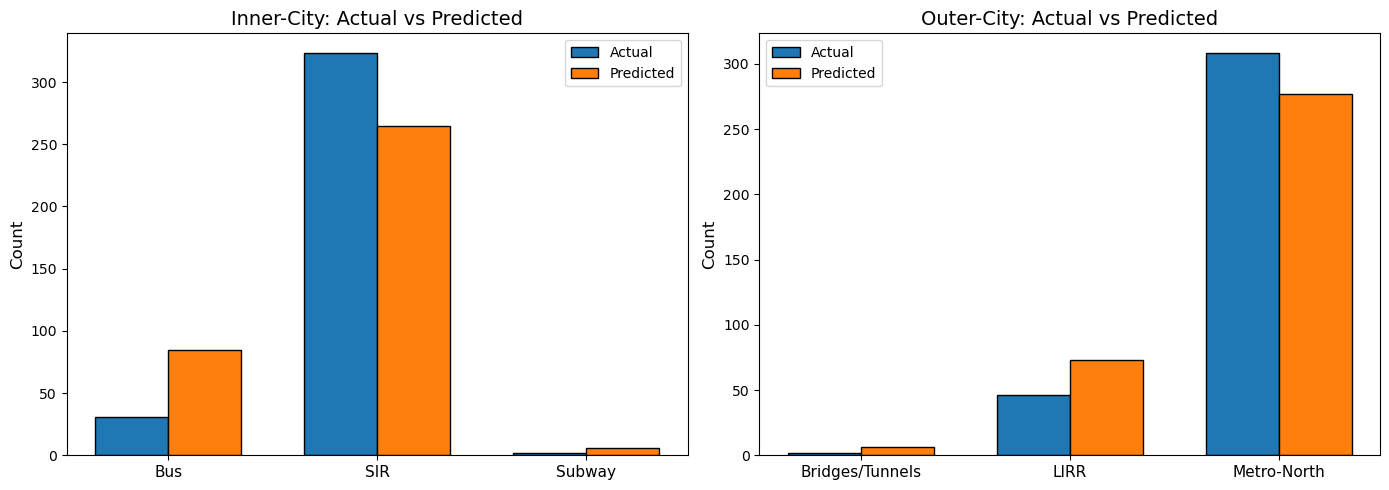

In [19]:
# ===================== PREP INNER =====================
actual_in  = y_test_in.value_counts().sort_index()
pred_in    = pd.Series(y_pred_in).value_counts().sort_index()
labels_in  = actual_in.index
x_in       = np.arange(len(labels_in))

# ===================== PREP OUTER =====================
actual_out = y_test_out.value_counts().sort_index()
pred_out   = pd.Series(y_pred_out).value_counts().sort_index()
labels_out = actual_out.index
x_out      = np.arange(len(labels_out))

bar_width = 0.35

plt.figure(figsize=(14,5))

# ======================================================
# LEFT PLOT — INNER CITY
# ======================================================
plt.subplot(1, 2, 1)

plt.bar(
    x_in - bar_width/2,
    actual_in,
    width=bar_width,
    label="Actual",
    color="#1f77b4",
    edgecolor="black"
)

plt.bar(
    x_in + bar_width/2,
    pred_in,
    width=bar_width,
    label="Predicted",
    color="#ff7f0e",
    edgecolor="black"
)

plt.title("Inner-City: Actual vs Predicted", fontsize=14)
plt.ylabel("Count", fontsize=12)
plt.xticks(x_in, labels_in, fontsize=11)
plt.legend()

# ======================================================
# RIGHT PLOT — OUTER CITY
# ======================================================
plt.subplot(1, 2, 2)

plt.bar(
    x_out - bar_width/2,
    actual_out,
    width=bar_width,
    label="Actual",
    color="#1f77b4",
    edgecolor="black"
)

plt.bar(
    x_out + bar_width/2,
    pred_out,
    width=bar_width,
    label="Predicted",
    color="#ff7f0e",
    edgecolor="black"
)

plt.title("Outer-City: Actual vs Predicted", fontsize=14)
plt.ylabel("Count", fontsize=12)
plt.xticks(x_out, labels_out, fontsize=11)
plt.legend()

plt.tight_layout()
plt.show()

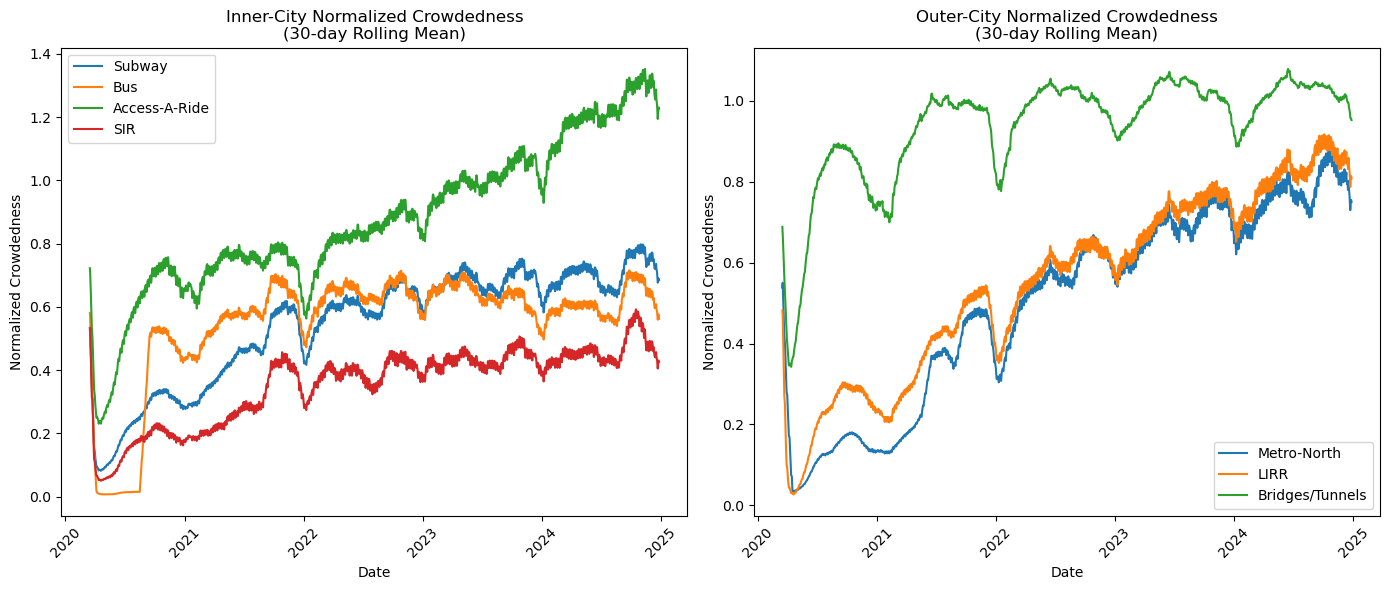

In [20]:
# =====================================================
# INNER-CITY TREND DATA (smoothed)
# =====================================================

inner_trend = inner_norm.copy()
inner_trend['Date'] = df['Date']
inner_trend = inner_trend.sort_values('Date')

window_size = 30
inner_smooth = inner_trend.copy()

for col in ['Subway', 'Bus', 'Access-A-Ride', 'SIR']:
    inner_smooth[col] = inner_trend[col].rolling(
        window=window_size, center=True
    ).mean()

# =====================================================
# OUTER-CITY TREND DATA (smoothed)
# =====================================================

outer_trend = outer_norm.copy()
outer_trend['Date'] = df['Date']
outer_trend = outer_trend.sort_values('Date')

outer_smooth = outer_trend.copy()

for col in ['Metro-North', 'LIRR', 'Bridges/Tunnels']:
    outer_smooth[col] = outer_trend[col].rolling(
        window=window_size, center=True
    ).mean()

# =====================================================
# COMBINED PLOT (TWO SUBPLOTS)
# =====================================================

plt.figure(figsize=(14, 6))

# ---------------------- INNER CITY ----------------------
plt.subplot(1, 2, 1)
plt.plot(inner_smooth['Date'], inner_smooth['Subway'], label='Subway')
plt.plot(inner_smooth['Date'], inner_smooth['Bus'], label='Bus')
plt.plot(inner_smooth['Date'], inner_smooth['Access-A-Ride'], label='Access-A-Ride')
plt.plot(inner_smooth['Date'], inner_smooth['SIR'], label='SIR')

plt.title('Inner-City Normalized Crowdedness\n(30-day Rolling Mean)')
plt.xlabel('Date')
plt.ylabel('Normalized Crowdedness')
plt.legend()
plt.xticks(rotation=45)

# ---------------------- OUTER CITY ----------------------
plt.subplot(1, 2, 2)
plt.plot(outer_smooth['Date'], outer_smooth['Metro-North'], label='Metro-North')
plt.plot(outer_smooth['Date'], outer_smooth['LIRR'], label='LIRR')
plt.plot(outer_smooth['Date'], outer_smooth['Bridges/Tunnels'], label='Bridges/Tunnels')

plt.title('Outer-City Normalized Crowdedness\n(30-day Rolling Mean)')
plt.xlabel('Date')
plt.ylabel('Normalized Crowdedness')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 12. Conclusions

### Model Performance
| Model | Modes | Accuracy |
|---|---|---|
| Inner-City Random Forest | Subway, Bus, Access-A-Ride, SIR | ~65% |
| Outer-City Random Forest | Metro-North, LIRR, Bridges/Tunnels | ~78% |

### Key Takeaways for an NJ Commuter
- **Staten Island Railway** is consistently the least crowded inner-city mode
- **Metro-North** is the least crowded outer-city commuter option, especially mid-week
- Crowdedness is strongly driven by **week of year** and **month** (seasonal effects), more so than holidays
- All modes show clear pandemic recovery curves, with car travel (Bridges & Tunnels) recovering fastest

### Limitations
- Calendar features alone cannot capture weather, major events, or service disruptions
- Class imbalance limits predictions for rarely 'least crowded' modes
- Pre-pandemic baselines used for normalization may have shifted post-COVID


## 12. Conclusions

### Model Performance
| Model | Modes | Accuracy |
|---|---|---|
| Inner-City Random Forest | Subway, Bus, Access-A-Ride, SIR | ~65% |
| Outer-City Random Forest | Metro-North, LIRR, Bridges/Tunnels | ~78% |

### Key Takeaways for an NJ Commuter
- **Staten Island Railway** is the least crowded inner-city mode on ~90% of days
- **Metro-North** is the least crowded outer-city option on ~86% of days, 
  particularly mid-week
- All modes show clear pandemic recovery curves. Bridges & Tunnels recovered 
  fastest, suggesting car travel rebounded before public transit
- Holidays suppress subway and bus ridership by ~45%, but only reduce car 
  traffic by ~18%, drivers are less affected by public holidays

### Caveats & Model Limitations
- **Class imbalance** is the biggest issue: SIR dominates inner-city labels 
  (1,610 of 1,776 days) and Metro-North dominates outer-city (1,535 days). 
  The models largely learn to predict the majority class, which inflates accuracy
- **Season alone is a weak predictor** the seasonal linear regression produced 
  negative R^2 on test data, meaning it performs worse than simply predicting the 
  mean. Ridership variance is driven more by the pandemic recovery period than 
  by season
- **Calendar features have a ceiling** day of week, month, and holidays cannot 
  capture weather, service disruptions, major events, or school schedules, all of 
  which meaningfully affect ridership

### What Would Improve This
- Incorporating **weather data** (precipitation, temperature) as features
- Adding **school calendar** flags term-time vs. holiday periods drive large 
  ridership swings on commuter rail
- Retraining on **post-2022 data only** to remove the pandemic distortion, which 
  currently dominates the variance in every model